# 📊 Descriptive Statistics & Data Visualization (Kaggle Heart Disease Dataset)

By: Adeline Marie Obordo

This project explores a Kaggle heart‑disease dataset using Python to perform descriptive statistics and create meaningful visualizations. The goal is to understand variable distributions, identify relationships among clinical features, and highlight patterns associated with heart‑disease presence.

## 🔍 Key Steps
- Loaded and prepared the dataset using **pandas** and **NumPy**
- Computed descriptive statistics (mean, median, variance, skewness, kurtosis, IQR, etc.)
- Generated a **Pearson correlation matrix** to examine linear relationships

## 📈 Visualizations Included
- **Correlation heatmap** (coolwarm palette)
- **Pairplot** (scatterplot matrix for multivariate analysis)
- **Histograms with KDE**, grouped by disease condition
- **Countplot** of sex vs. condition
- **Violin plot** of age distribution by condition
- **Boxplot** of cholesterol levels by chest‑pain type
- **Hexbin jointplot** of age vs. cholesterol

## 🛠️ Tools & Libraries
- `pandas`
- `numpy`
- `scipy`
- `matplotlib`
- `seaborn`

This notebook demonstrates a complete exploratory data analysis workflow using real-world health data, combining statistical profiling with clear, insightful visualizations.


## 🗃️ Dataset Description

**Key Features Included:**
*   `age`: Age of the patient (in years)
*   `sex`: Gender of the patient (1 = male; 0 = female)
*   `cp`: Chest pain type (e.g., typical angina, atypical angina, non-anginal pain, asymptomatic)
*   `trestbps`: Resting blood pressure (in mmHg)
*   `chol`: Serum cholesterol (in mg/dl)
*   `fbs`: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
*   `restecg`: Resting electrocardiographic results (0, 1, 2)
*   `thalach`: Maximum heart rate achieved
*   `exang`: Exercise induced angina (1 = yes; 0 = no)
*   `oldpeak`: ST depression induced by exercise relative to rest
*   `slope`: The slope of the peak exercise ST segment
*   `ca`: Number of major vessels (0-3) colored by fluoroscopy
*   `thal`: Thalassemia (0 = normal; 1 = fixed defect; 2 = reversible defect)
*   `condition`: Diagnosis of heart disease (angiographic disease status) (0 = no disease; 1 = disease presence)

Decriptive Statistics

In [2]:
# %pip install pandas numpy scipy seaborn matplotlib

In [3]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Heart Data.xlsx'

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import os


file_path = '/content/drive/MyDrive/Heart Data.xlsx'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please ensure the file is in your Google Drive and the path is correct.")
    # Optionally, you can stop execution here or ask for a new path
else:
    df = pd.read_excel(file_path)


# Select numeric columns only
numeric_df = df.select_dtypes(include=['number'])

#Step 1: Compute Quantitative Stat Metrics for Numeric Data and Saved Results in Excel

if numeric_df.empty:
    print("No numeric columns found in the Excel file.")

else:
    # Compute descriptive statistics
    mean = numeric_df.mean()
    median = numeric_df.median()
    variance = numeric_df.var()
    std_dev = numeric_df.std()
    minimum = numeric_df.min()
    maximum = numeric_df.max()
    count = numeric_df.count()
    mode = numeric_df.mode().iloc[0]
    kurt = numeric_df.apply(kurtosis)
    skewness = numeric_df.apply(skew)
    q = numeric_df.quantile([0.25, 0.5, 0.75])
    IQR = q.loc[0.75] - q.loc[0.25]
    Sum = numeric_df.sum()

    # Combine into a single DataFrame
    stats_df = pd.DataFrame({
        "Count": count,
        "Minimum": minimum,
        "Maximum": maximum,
        "Mean": mean,
        "Median": median,
        "Mode": mode,
        "Variance": variance,
        "Standard Deviation": std_dev,
        "25th Percentile": q.loc[0.25],
        "50th Percentile": q.loc[0.50],
        "75th Percentile": q.loc[0.75],
        "Kurtosis": kurt,
        "Skewness": skewness,
        "IQR": IQR,
        "Sum": Sum
    })

    # Transpose for readability
    stats_df = stats_df.transpose()

    # Display the descriptive statistics in the notebook
    stats_df


In [7]:
# Transpose for readability
stats_df = stats_df.transpose()

In [ ]:
stats_df

,Count,Minimum,Maximum,Mean,Median,Mode,Variance,Standard Deviation,25th Percentile,50th Percentile,75th Percentile,Kurtosis,Skewness,IQR,Sum
age,297.0,29.0,77.0,54.542088,56.0,58.0,81.897716,9.049736,48.0,56.0,61.0,-0.533146,-0.218663,13.0,16199.0
sex,297.0,0.0,1.0,0.676768,1.0,1.0,0.219492,0.468500,0.0,1.0,1.0,-1.428638,-0.755885,1.0,201.0
cp,297.0,0.0,3.0,2.158249,2.0,3.0,0.930954,0.964859,2.0,2.0,3.0,-0.424174,-0.840142,1.0,641.0
trestbps,297.0,94.0,200.0,131.693603,130.0,120.0,315.517290,17.762806,120.0,130.0,140.0,0.781192,0.696529,20.0,39113.0
chol,297.0,126.0,564.0,247.350168,243.0,197.0,2703.748589,51.997583,211.0,243.0,276.0,4.349479,1.112441,65.0,73463.0
fbs,297.0,0.0,1.0,0.144781,0.0,0.0,0.124238,0.352474,0.0,0.0,0.0,2.076268,2.018977,0.0,43.0
restecg,297.0,0.0,2.0,0.996633,1.0,0.0,0.989853,0.994914,0.0,1.0,2.0,-1.986302,0.006734,2.0,296.0
thalach,297.0,71.0,202.0,149.599327,153.0,162.0,526.315270,22.941562,133.0,153.0,166.0,-0.071115,-0.533826,33.0,44431.0
exang,297.0,0.0,1.0,0.326599,0.0,0.0,0.220675,0.469761,0.0,0.0,1.0,-1.453144,0.739497,1.0,97.0
oldpeak,297.0,0.0,6.2,1.055556,0.8,0.0,1.359842,1.166123,0.0,0.8,1.6,1.465520,1.240824,1.6,313.5


### Interpretation of Descriptive Statistics (`stats_df`)

The `stats_df` DataFrame provides a comprehensive overview of the numerical features in the dataset. Here's an interpretation of key metrics:

*   **Dataset Size**: All features have a `Count` of 297, indicating no missing values in the dataset.

*   **Age**: The mean age is approximately 54.5 years, with a median of 56 years. The slight negative `Skewness` (-0.21) suggests a distribution that is slightly skewed towards younger ages. Ages range from 29 to 77.

*   **Sex**: The `Mean` of 0.676 and `Mode` of 1 (assuming 1 represents male and 0 represents female) indicate that approximately 67% of the participants in this dataset are male. The negative `Skewness` (-0.75) is consistent with more observations at the higher end (male).

*   **Chest Pain Type (cp)**: The `Mode` is 3, suggesting that 'typical angina' is the most common chest pain type among the participants. The `Mean` (2.15) and `Median` (2.0) are relatively close, with a negative `Skewness` (-0.84).

*   **Resting Blood Pressure (trestbps)**: The average resting blood pressure is around 131.7 mmHg, with a median of 130 mmHg. A positive `Skewness` (0.69) suggests a slight tail towards higher blood pressure values. The range is from 94 to 200 mmHg.

*   **Cholesterol (chol)**: The `Mean` cholesterol level is about 247.35 mg/dl, with a `Median` of 243 mg/dl. The positive `Skewness` (1.11) indicates a distribution with a tail extending towards higher cholesterol levels. The high positive `Kurtosis` (4.34) suggests a more peaked distribution with potentially fatter tails, which could imply the presence of some very high cholesterol readings (outliers).

*   **Maximum Heart Rate Achieved (thalach)**: The `Mean` maximum heart rate is 149.6 bpm, and the `Median` is 153 bpm. A slight negative `Skewness` (-0.53) implies a distribution slightly skewed towards higher heart rates.

*   **Oldpeak**: This feature, representing ST depression induced by exercise, shows a `Mean` of 1.05 and a `Median` of 0.8. The `Mode` is 0, meaning many individuals had no ST depression. The significant positive `Skewness` (1.24) and `Kurtosis` (1.46) indicate a distribution with a prominent tail of higher oldpeak values and potential outliers.

*   **Heart Disease Condition (condition)**: The `Mean` of 0.461 implies that approximately 46% of the participants in this dataset have heart disease (where 1 indicates disease presence and 0 indicates no disease). The `Median` of 0 further suggests that slightly more than half of the dataset consists of individuals without heart disease.

Overall, `stats_df` highlights important characteristics of the data, including central tendencies, spread, and the shape of distributions (skewness and kurtosis), which are crucial for understanding the dataset before further analysis.

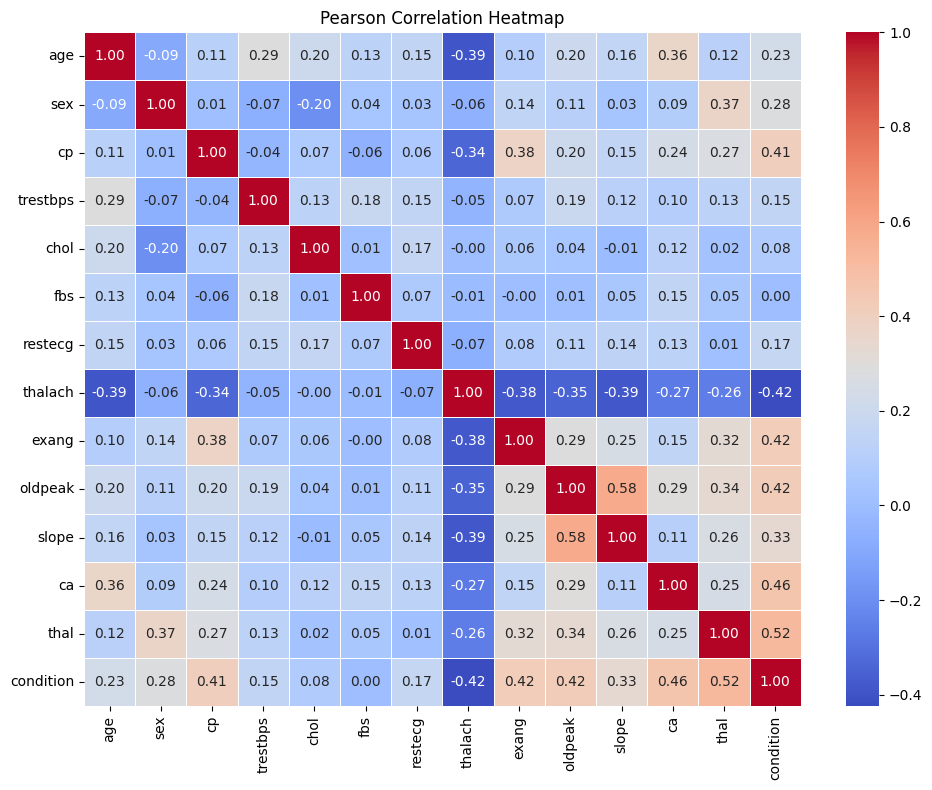

In [8]:
# Step 2: Compute Pearson correlation

correlation_matrix = numeric_df.corr(method='pearson')

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()


## Pearson correlation coefficient (r):
- Measures the linear relationship between two variables.

- Range: -1 to +1

- r = +1: perfect positive linear relationship (y is increasing with x linearly)

- r = 0: no linear relationship

- r = -1: perfect negative linear relationship (if x is increasing, y is decreasing
linearly)

## How to Read the Heatmap

- Rows and Columns: Each row and column represents a variable.

- Color Intensity: The cell color encodes the strength and direction of correlation:

- Dark Red / Deep Blue (depending on color scheme): Very strong correlation (positive or negative).

- Pale / Near White: Weak or no correlation.

- Diagonal Cells: Always show 1.0 (a variable is perfectly correlated with itself).

### Interpretation of the Pearson Correlation Heatmap

The heatmap visually represents the linear relationships between all pairs of numerical variables in the dataset. Here are some key observations:

*   **Target Variable (`condition`) Correlations**:
    *   **Positive Correlations (Risk Factors)**: `cp` (chest pain type, 0.43), `exang` (exercise induced angina, 0.44), `oldpeak` (ST depression induced by exercise, 0.42), `ca` (number of major vessels colored by fluoroscopy, 0.46), and `thal` (thallium scan result, 0.52) show moderate to strong positive correlations with `condition`. This suggests that higher values or certain types in these features are associated with a higher likelihood of heart disease.
    *   **Negative Correlations (Protective/Inverse Factors)**: `thalach` (maximum heart rate achieved, -0.42) and `slope` (the slope of the peak exercise ST segment, -0.34) have moderate negative correlations with `condition`. This implies that a higher maximum heart rate or a particular slope type is associated with a lower likelihood of heart disease.
    *   **Weak Correlations**: `age` (0.23), `sex` (-0.28), `trestbps` (resting blood pressure, 0.16), and `chol` (cholesterol, 0.08) show relatively weaker correlations with `condition`. While statistically significant, their linear relationship with heart disease presence is not as strong as the other factors.

*   **Inter-Feature Correlations**:
    *   **`thalach` and `age`**: There's a notable negative correlation between `thalach` and `age` (-0.39), which is expected as maximum heart rate tends to decrease with age.
    *   **`oldpeak` and `thalach`**: A strong negative correlation (-0.35) exists, indicating that individuals with higher maximum heart rates achieved during exercise tend to have lower ST depression.
    *   **`cp` and other variables**: `cp` (chest pain type) shows moderate positive correlations with `condition` but weaker, mixed correlations with other physiological measures.
    *   **`trestbps` (Resting Blood Pressure) and `age`**: A positive correlation of 0.29, suggesting blood pressure tends to increase with age.

In summary, the correlation heatmap highlights several features (`cp`, `thalach`, `exang`, `oldpeak`, `ca`, `thal`) that have more substantial linear relationships with the presence of heart disease, making them potentially important predictors for further modeling. Other correlations provide insight into the physiological interdependencies within the dataset.

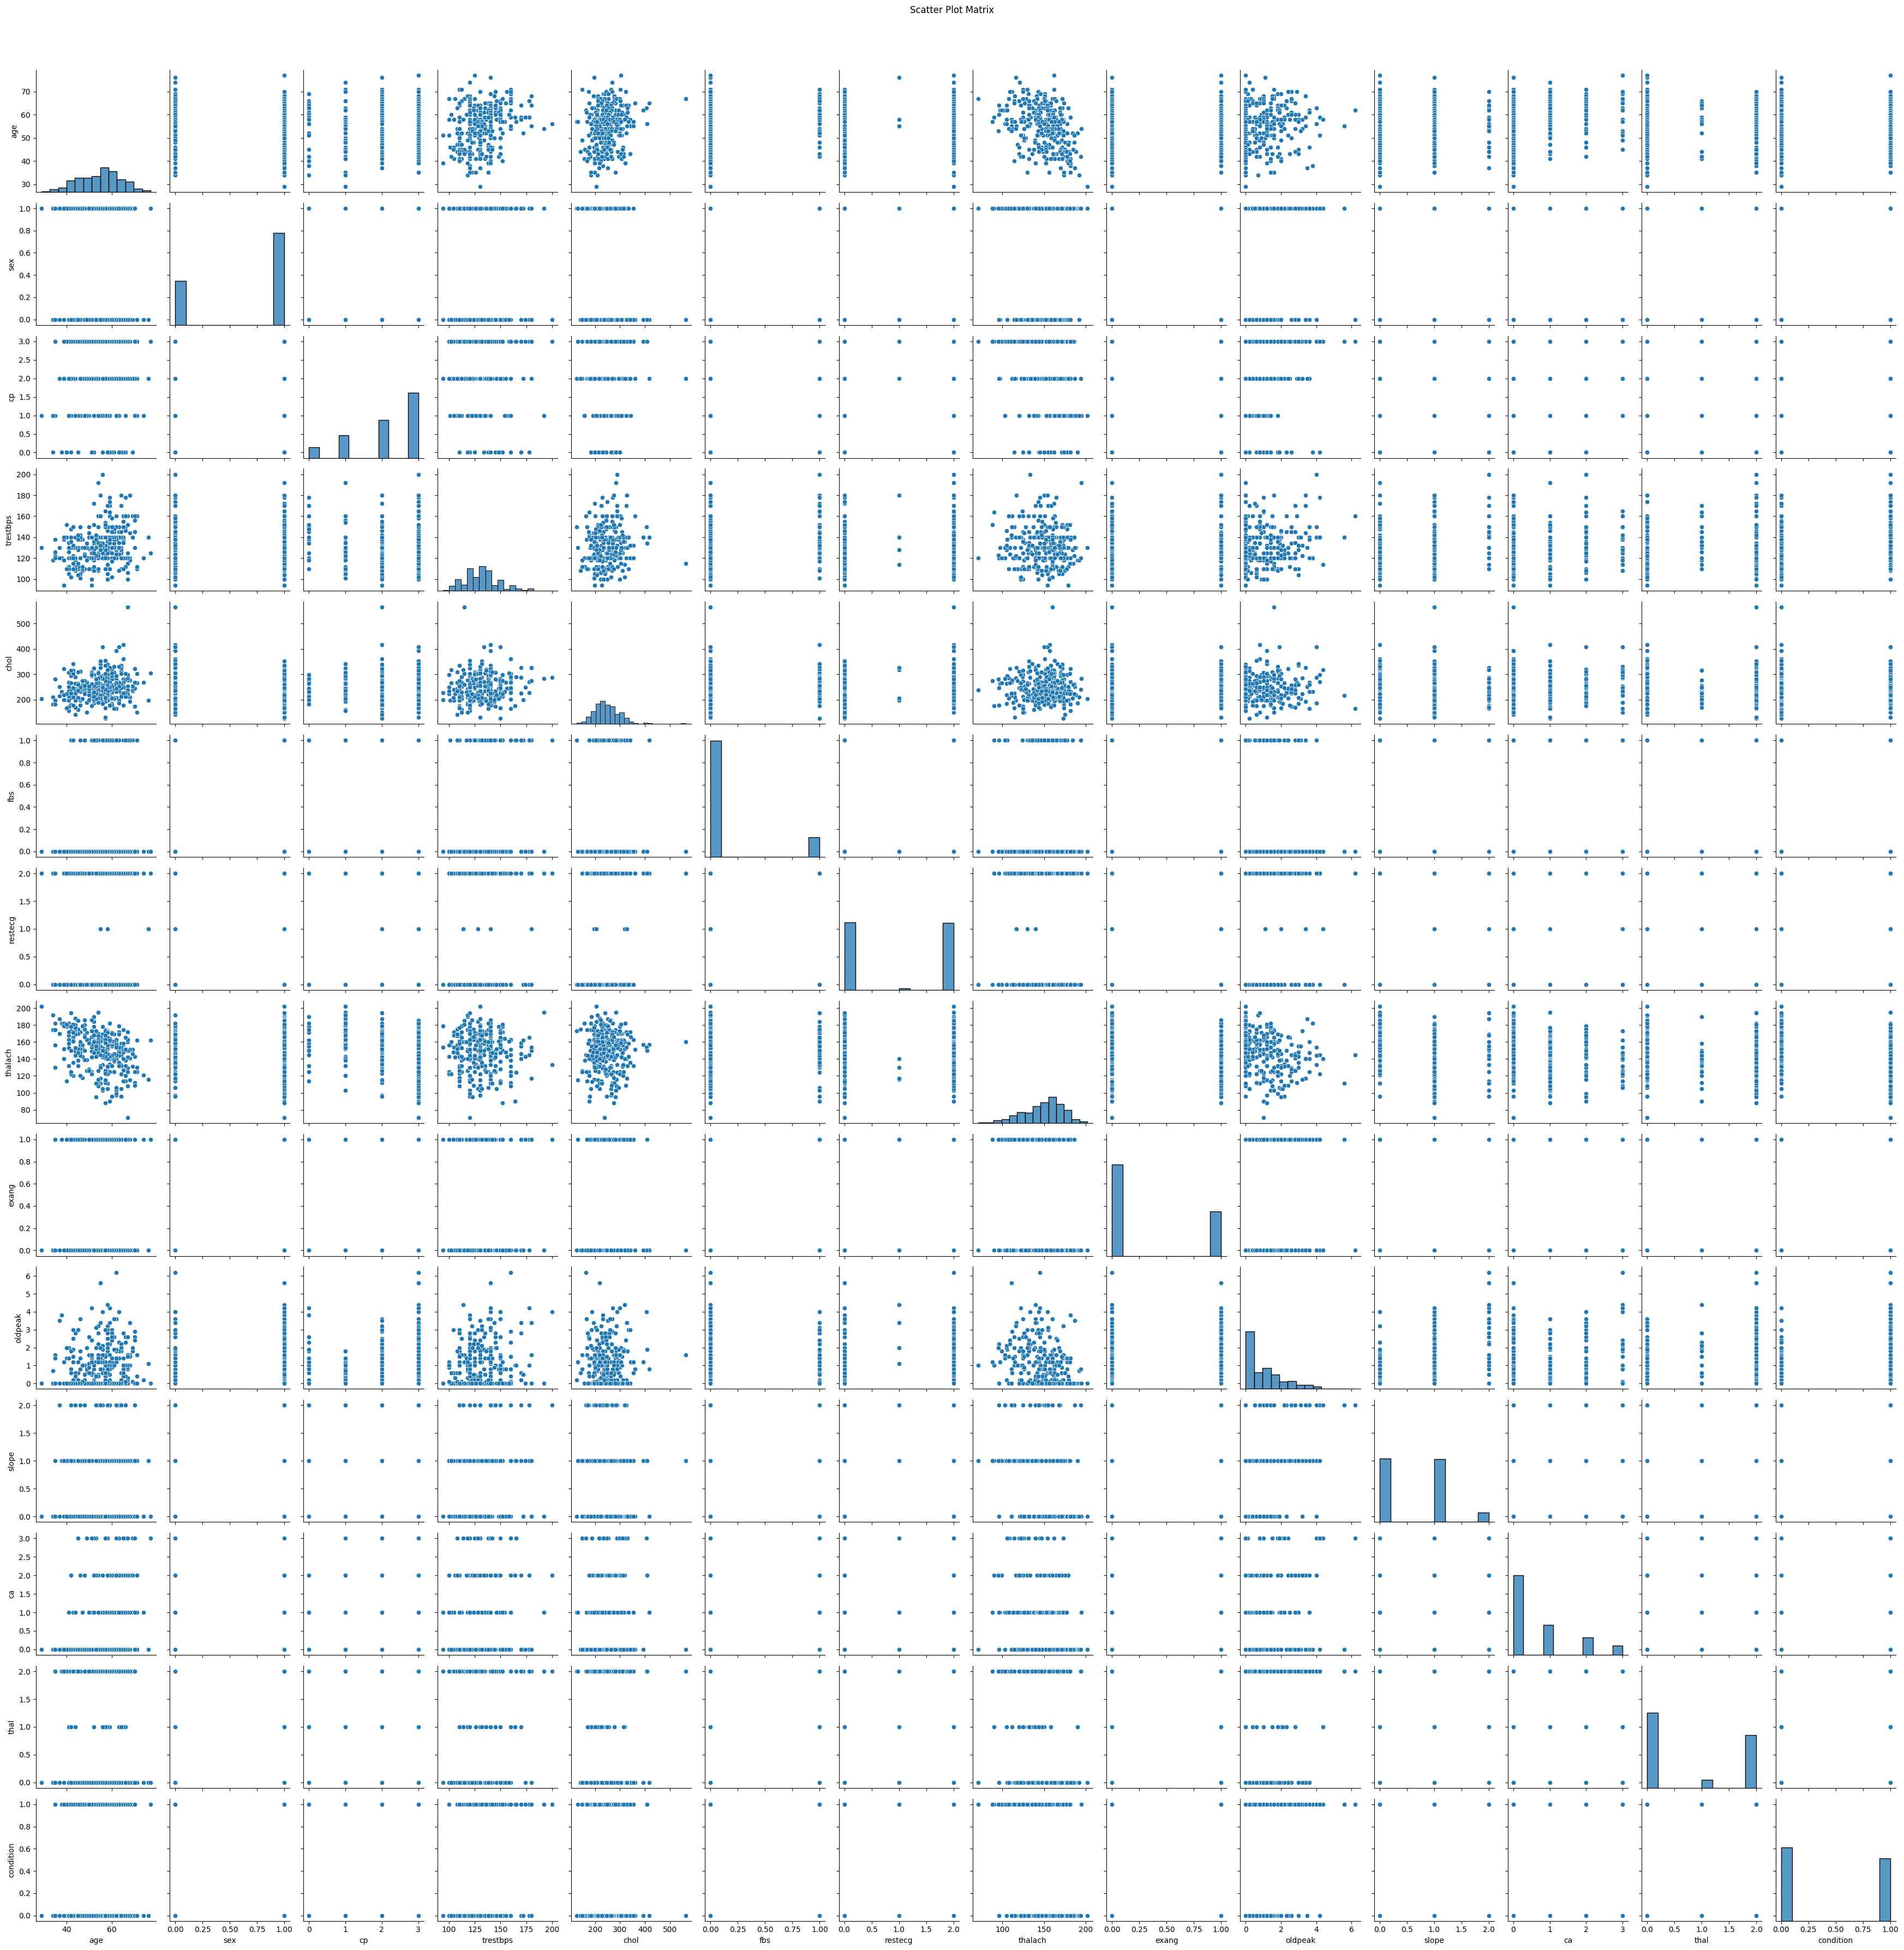

In [9]:
# Step 4: Scatter plot matrix (pairplot)
sns.pairplot(numeric_df)
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.tight_layout()
plt.show()

### Interpretation of the Scatter Plot Matrix (Pairplot)

The scatter plot matrix, generated using `sns.pairplot(numeric_df)`, provides a comprehensive visualization of the relationships between all numerical variables in the dataset. Each subplot serves a specific purpose:

*   **Diagonal Plots**: The plots along the diagonal show the univariate distribution of each variable. These are typically histograms or Kernel Density Estimates (KDEs), giving a quick overview of the shape, spread, and central tendency of individual features. For example, you can observe if a variable is normally distributed, skewed, or has multiple modes.

*   **Off-Diagonal Plots**: The off-diagonal plots display scatter plots for every possible pair of variables. These plots are crucial for identifying:
    *   **Linear Relationships**: If points tend to cluster along a straight line, it suggests a linear correlation, similar to what the Pearson correlation heatmap indicates. For instance, a clear upward or downward trend.
    *   **Non-Linear Relationships**: Sometimes, variables might be related but not linearly (e.g., a curved pattern). A pairplot can reveal these more complex relationships.
    *   **Clusters and Outliers**: Groups of data points (clusters) or isolated points (outliers) can be easily spotted, which might indicate different subgroups within the data or data entry errors.
    *   **No Apparent Relationship**: If points are scattered randomly with no discernible pattern, it suggests a weak or no linear/non-linear relationship between the two variables.

**General Observations from this Pairplot**:

*   **Distribution Shapes**: The diagonal plots show a mix of distributions. Some, like `age` and `thalach`, appear somewhat normally distributed, while others, such as `exang`, `fbs`, and `condition`, are clearly categorical or binary, showing distinct bars.

*   **Relationship between `age` and `thalach`**: The scatter plot between `age` and `thalach` (maximum heart rate achieved) often shows a negative trend, indicating that as age increases, the maximum heart rate tends to decrease, which is a known physiological phenomenon.

*   **Relationships with `condition`**: While a direct strong linear relationship for all variables with `condition` might not be immediately obvious in all scatter plots (especially for binary outcomes like `condition`), you can sometimes observe subtle trends. For example, some plots might show denser clusters of 'condition=1' at higher values of certain risk factors or lower values of protective factors. The pairplot serves as a visual precursor to more detailed analysis, allowing for the qualitative assessment of how features interact and how they might influence the presence of heart disease.

*   **Potential Outliers**: The scatter plots can also help identify potential outliers in bivariate relationships, where a few points lie far away from the main cloud of data, warranting further investigation.

In summary, the scatter plot matrix is an excellent exploratory tool for visually assessing the individual distributions of variables and their pairwise relationships, which complements the quantitative insights from the correlation matrix and descriptive statistics.

### Additional Plots using Seaborn

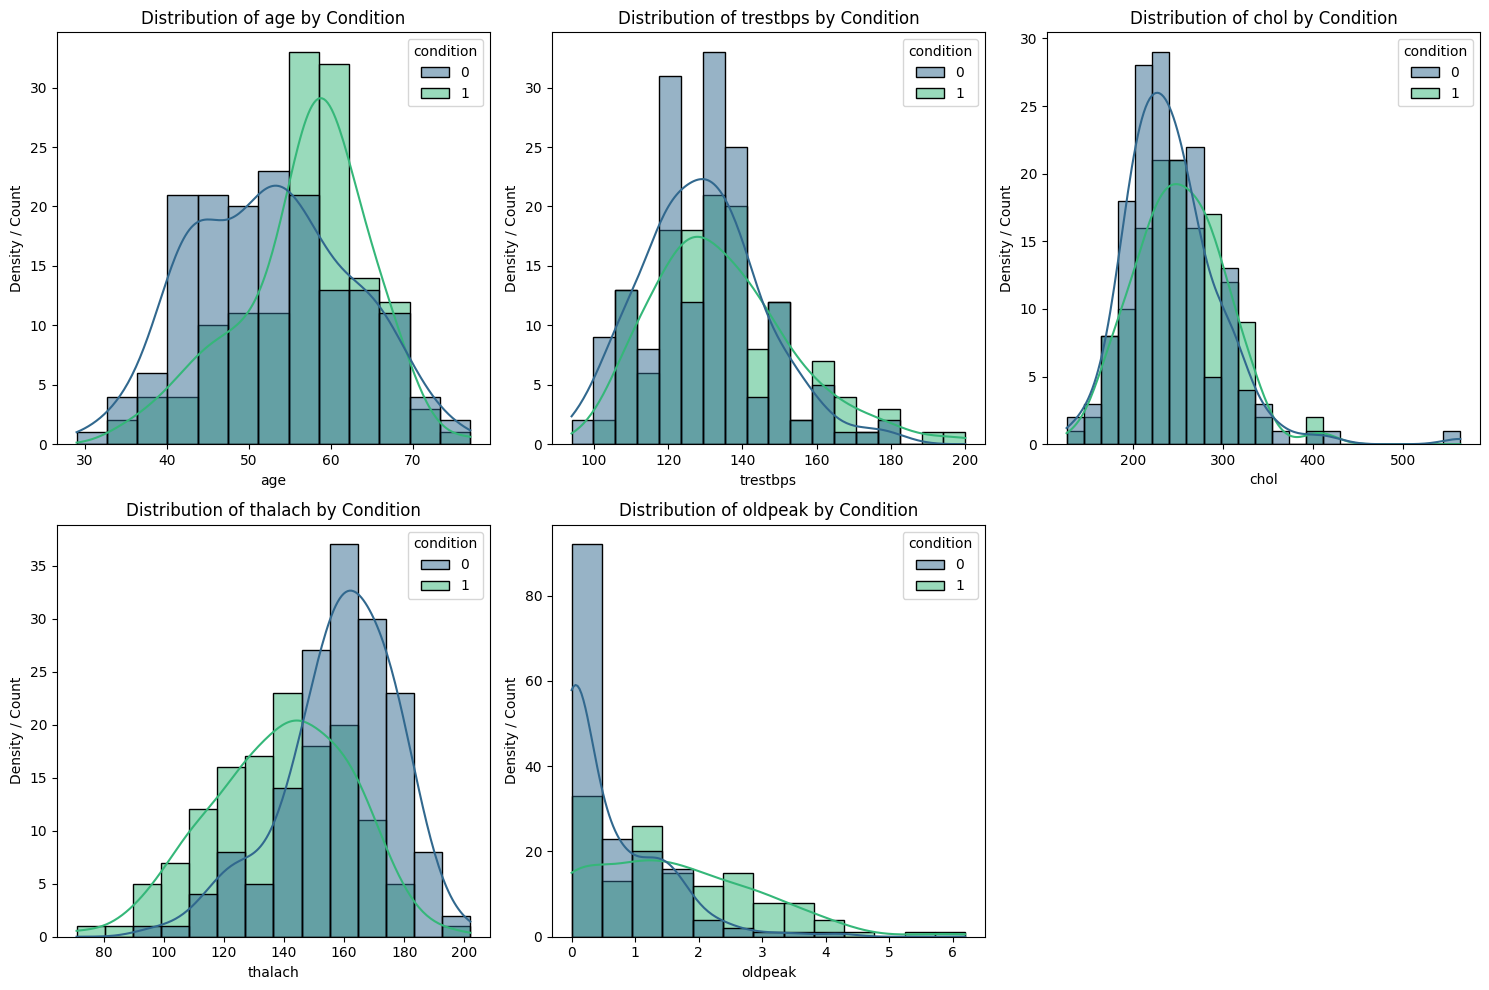

In [10]:
# Plot 1: Histograms/KDEs for key numerical features, separated by 'condition'

selected_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.histplot(data=df, x=feature, hue='condition', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature} by Condition')
    plt.xlabel(feature)
    plt.ylabel('Density / Count')

plt.tight_layout()
plt.show()

### Interpretation of Histograms with KDE (Grouped by 'condition')

These plots display the distribution of key numerical features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) for both individuals with and without heart disease (`condition`). The histograms show the frequency of values within bins, while the Kernel Density Estimates (KDEs) provide a smoothed representation of the distribution.

**General Observations from these Plots**:

*   **Age Distribution**: Observing the 'age' plot, you can see how the age distributions differ between those with and without heart disease. Often, heart disease might be more prevalent in older age groups, indicated by a shift in the distribution towards higher ages for `condition=1`.

*   **Resting Blood Pressure (`trestbps`)**: These plots allow us to visually compare the distribution of resting blood pressure between the two condition groups. We might observe if patients with heart disease tend to have higher blood pressure, or if the distributions are largely overlapping.

*   **Cholesterol (`chol`)**: Similar to `trestbps`, the cholesterol plots help visualize if there's a noticeable difference in cholesterol levels between healthy individuals and those with heart disease. A shift or wider spread for one group could be an indicator.

*   **Maximum Heart Rate Achieved (`thalach`)**: This plot is crucial for understanding the distribution of `thalach` for each group. For instance, if individuals with heart disease tend to have a lower maximum heart rate achieved, their distribution curve would likely be shifted to the left compared to those without the condition.

*   **Oldpeak**: The distribution of `oldpeak` (ST depression induced by exercise relative to rest) can reveal if individuals with heart disease tend to have higher values, indicating greater exercise-induced ST depression. The presence of distinct peaks or tails for each group is informative.

By comparing the shapes, centers, and spreads of the distributions for `condition=0` (no disease) and `condition=1` (disease), these plots provide immediate visual insights into which numerical features might be strong indicators or risk factors for heart disease. Features with clearly separated or distinctly shaped distributions between the two groups are likely to be more discriminative.

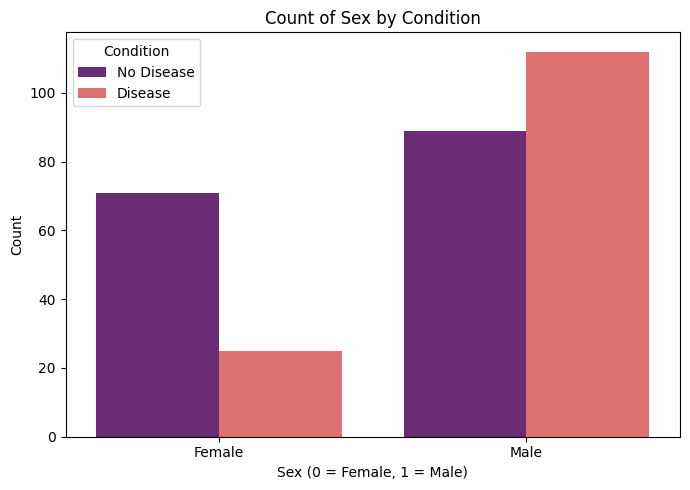

In [11]:
# Plot 2: Countplot for 'sex' by 'condition'

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='sex', hue='condition', palette='magma')
plt.title('Count of Sex by Condition')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Condition', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

### Interpretation of Countplot: Sex vs. Condition

This countplot visualizes the distribution of individuals based on their `sex` (0 = Female, 1 = Male) and their `condition` (0 = No Disease, 1 = Disease). It allows us to quickly assess the number of males and females in the dataset and how heart disease prevalence differs between these two groups.

**General Observations**:

*   **Overall Sex Distribution**: The plot shows the absolute counts for each sex. By comparing the heights of the 'Male' and 'Female' bars (summing across both conditions), we can see the overall gender balance in the dataset.

*   **Heart Disease Prevalence by Sex**: Each gender bar is segmented by `condition` (No Disease vs. Disease). This clearly illustrates:
    *   **For Males**: The proportion of males with and without heart disease. We can observe if a larger fraction of males in this dataset have the condition.
    *   **For Females**: The proportion of females with and without heart disease. Similarly, we can see their disease prevalence.

*   **Comparative Insights**: By comparing the 'No Disease' and 'Disease' segments across genders, we can draw conclusions about which sex group has a higher or lower incidence of heart disease within this dataset. For instance, if the 'Disease' segment is significantly larger for males than for females, it suggests a higher prevalence in males.

This plot provides immediate, clear visual evidence of how sex might be associated with the presence of heart disease in the given data, making it a valuable tool for initial exploratory analysis of categorical variables against a binary outcome.

/tmp/ipykernel_2355/1511535077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='condition', y='age', palette='coolwarm')


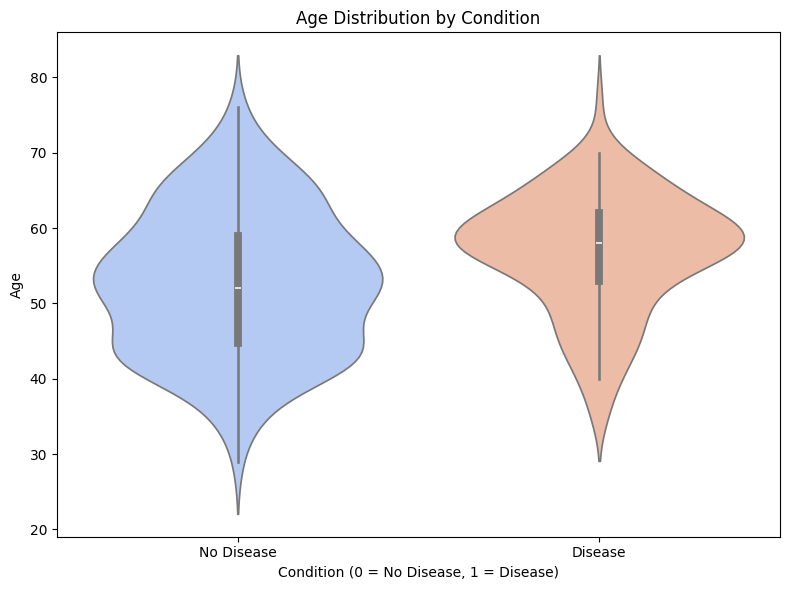

In [12]:
# Plot 3: Violin plot for 'age' by 'condition'

plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='condition', y='age', palette='coolwarm')
plt.title('Age Distribution by Condition')
plt.xlabel('Condition (0 = No Disease, 1 = Disease)')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

### Interpretation of Violin Plot: Age Distribution by Condition

This violin plot visualizes the distribution of `age` for each `condition` group (0 = No Disease, 1 = Disease). Violin plots combine aspects of box plots and kernel density plots, showing both the statistical summaries and the density of the data.

**Key Elements to Observe**:

*   **Box Plot Components**: Inside each violin, there's a mini box plot showing:
    *   **White Dot**: The median age for that condition group.
    *   **Thick Bar**: The interquartile range (IQR), representing the middle 50% of the data.
    *   **Thin Lines**: Extend to the minimum and maximum values within 1.5 times the IQR, indicating the typical range of data.

*   **Kernel Density Estimation (Shape of the Violin)**: The width of the violin at any given age level represents the density or frequency of individuals at that age. A wider section means more data points are concentrated there, while a narrower section indicates fewer.

**General Observations from this Plot**:

*   **Comparison of Age Distributions**: You can visually compare the central tendency (median), spread (IQR and range), and density of age between individuals with no heart disease and those with heart disease.

*   **Peak Age Ranges**: Look for the widest parts of each violin to identify the age ranges where each condition is most prevalent. For example, if the 'Disease' violin is wider at higher ages, it suggests heart disease is more common in older individuals.

*   **Symmetry and Skewness**: The shape of the violin can indicate if the age distribution within a group is symmetric or skewed. For instance, a longer tail on one side suggests a skew.

*   **Outliers**: While not explicitly shown with individual points like in a box plot, unusual thin extensions of the violin might suggest fewer data points at extreme ages.

This plot is excellent for understanding the detailed shape of the age distribution for each condition, providing more information than a simple box plot about where the data is concentrated.

/tmp/ipykernel_2355/4205537331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cp', y='chol', palette='Set3')


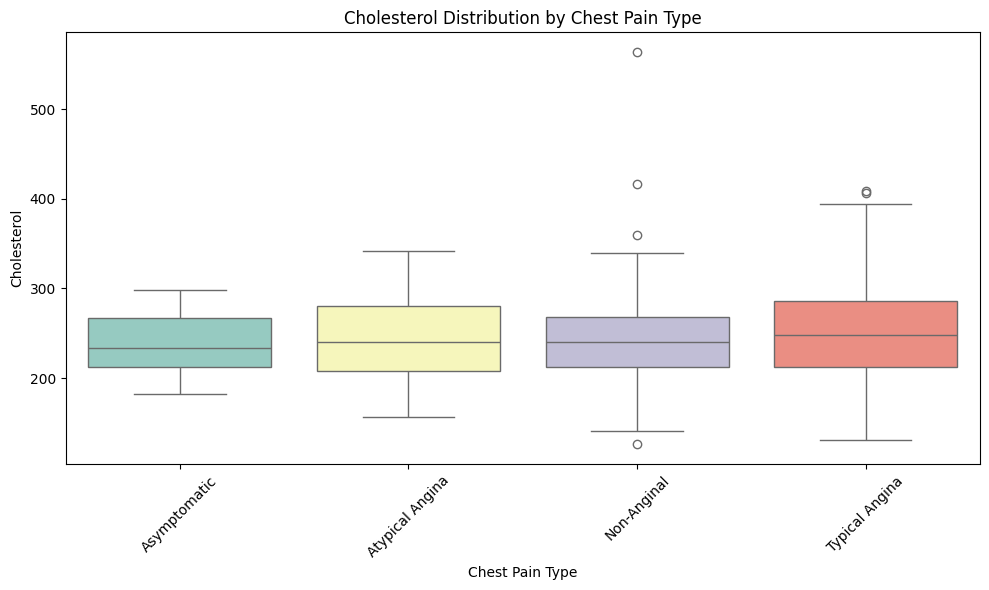

In [13]:
# Plot 4: Box plot for 'chol' by 'cp' (chest pain type)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cp', y='chol', palette='Set3')
plt.title('Cholesterol Distribution by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Cholesterol')
# Assuming cp is categorical: 0: asymptomatic, 1: atypical angina, 2: non-anginal pain, 3: typical angina
plt.xticks(ticks=[0, 1, 2, 3], labels=['Asymptomatic', 'Atypical Angina', 'Non-Anginal', 'Typical Angina'], rotation=45)
plt.tight_layout()
plt.show()

### Interpretation of Box Plot: Cholesterol by Chest Pain Type

This box plot visualizes the distribution of `chol` (cholesterol levels) for each `cp` (chest pain type). Box plots are excellent for comparing the distribution of a numerical variable across different categories.

**Key Elements to Observe in Each Box**:

*   **Central Line (Median)**: The line inside the box represents the median cholesterol level for that specific chest pain type.
*   **The Box (IQR)**: The box itself spans from the 25th percentile (Q1) to the 75th percentile (Q3), representing the interquartile range (IQR). This indicates the middle 50% of the data.
*   **Whiskers**: The lines (whiskers) extending from the box typically reach to the minimum and maximum values within 1.5 times the IQR from Q1 and Q3, respectively. They show the spread of the bulk of the data.
*   **Outliers**: Points beyond the whiskers are considered outliers and are plotted individually. These represent unusually high or low cholesterol levels for that chest pain type.

**General Observations from this Plot**:

*   **Comparison of Cholesterol Distributions**: You can easily compare the median cholesterol, the spread of the middle 50% of the data (IQR), and the presence of outliers across different chest pain types.

*   **Median Differences**: Observe if the median cholesterol levels vary significantly between different chest pain types. For example, one chest pain type might be associated with generally higher or lower median cholesterol.

*   **Variability**: The length of the boxes and whiskers indicates the variability or spread of cholesterol levels within each chest pain category. A longer box suggests greater variability.

*   **Outliers**: Pay attention to the number and magnitude of outliers. A significant number of outliers, or very extreme outliers, in a particular chest pain group could be an interesting finding.

This plot helps in understanding if certain chest pain types are associated with distinct patterns or ranges of cholesterol levels, which can be valuable for clinical insights.

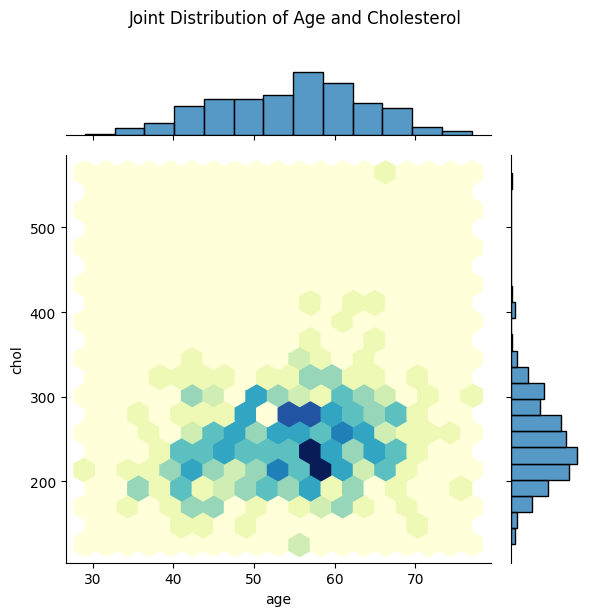

In [14]:
# Plot 5: Jointplot for 'age' and 'chol'

sns.jointplot(data=df, x='age', y='chol', kind='hex', cmap='YlGnBu')
plt.suptitle('Joint Distribution of Age and Cholesterol', y=1.02) # y is offset for suptitle
plt.tight_layout()
plt.show()

### Interpretation of Hexbin Jointplot: Age vs. Cholesterol

This jointplot visualizes the joint distribution of `age` and `chol` (cholesterol levels) using a hexbin plot. Hexbin plots are useful for visualizing the relationship between two numerical variables when there's a high density of data points, as they aggregate points into hexagonal bins and color them based on the count of observations within each bin.

**Key Elements to Observe**:

*   **Central Hexbin Plot**: The main part of the plot shows the bivariate distribution. The color intensity of each hexagon indicates the density of data points (i.e., how many individuals fall into that particular age and cholesterol range). A darker or more intense color (depending on the `cmap` used, e.g., 'YlGnBu') means a higher concentration of data points.

*   **Marginal Histograms/KDEs**: The plots along the top (for `age`) and right (for `chol`) margins show the univariate distributions of each variable individually. These are typically histograms or Kernel Density Estimates (KDEs), providing insights into the overall distribution, central tendency, and spread of `age` and `chol` without considering their relationship.

**General Observations from this Plot**:

*   **Joint Density**: Look for clusters of dark hexagons. These areas indicate where `age` and `cholesterol` values are most frequently observed together. This helps identify common profiles within the dataset.

*   **Relationship and Trends**: While the Pearson correlation heatmap provides a quantitative linear relationship, the hexbin plot offers a visual sense of any patterns. For example, you might observe if higher ages tend to be associated with higher cholesterol, or if there are specific age groups that exhibit a wider range of cholesterol levels.

*   **Outliers/Sparse Areas**: Areas with very light or no hexagons indicate combinations of age and cholesterol that are rare in the dataset. This can highlight potential outliers or less common physiological profiles.

*   **Distribution Shapes**: The marginal plots quickly show if `age` or `chol` are skewed, normally distributed, or have multiple peaks. For example, if the cholesterol marginal plot shows a tail extending to higher values, it aligns with positive skewness observed in descriptive statistics.

This jointplot is effective for understanding where the majority of the data lies in the bivariate space and can reveal patterns that might not be immediately obvious from individual distributions or simple correlation coefficients.